In [1]:
import os
os.chdir('/Users/jaywellik/jjwutils')

In [2]:
from obspy import read
from obspy import UTCDateTime, Stream

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

import numpy as np

from seismology.stream import createEmptyTrace
from seismology.stream.nslcobject import getNSLCstr
from plotutils.mplswarm.spectrogram import spectrogram
from plotutils.mplswarm.swarmplots import swarmw, swarmg, swarmwg

In [3]:
st = read('/Users/jaywellik/DATA/continuous/2017/VG/TMKS/EHZ.D/VG.TMKS.00.EHZ.D.2017.329.mseed')
st+= read('/Users/jaywellik/DATA/continuous/2017/VG/PSAG/EHZ.D/VG.PSAG.00.EHZ.D.2017.329.mseed')
st+= read('/Users/jaywellik/DATA/continuous/2017/VG/ABNG/SHZ.D/VG.ABNG.00.SHZ.D.2017.329.mseed')
st+= createEmptyTrace('VG.YHKR.00.BHZ', starttime=st[0].stats.starttime, endtime=st[0].stats.endtime, sampling_rate=100)
st+= read('/Users/jaywellik/DATA/continuous/2017/VG/CEGI/BHZ.D/VG.CEGI.00.BHZ.D.2017.329.mseed')
st = st.filter('bandpass', freqmin=1, freqmax=6, corners=2, zerophase=True)
st

5 Trace(s) in Stream:
VG.TMKS.00.EHZ | 2017-11-25T00:00:00.000001Z - 2017-11-25T23:59:59.980001Z | 100.0 Hz, 8639999 samples
VG.PSAG.00.EHZ | 2017-11-25T00:00:00.000001Z - 2017-11-25T23:59:59.980001Z | 100.0 Hz, 8639999 samples
VG.ABNG.00.SHZ | 2017-11-25T00:00:00.005000Z - 2017-11-25T23:59:59.985000Z | 50.0 Hz, 4320000 samples
VG.YHKR.00.BHZ | 2017-11-25T00:00:00.000001Z - 2017-11-25T23:59:59.970001Z | 100.0 Hz, 8639998 samples
VG.CEGI.00.BHZ | 2017-11-25T00:00:00.000000Z - 2017-11-25T23:59:59.980000Z | 50.0 Hz, 4320000 samples

In [4]:
st
cmap = 'plasma' # 'jet' | 'plasma' | 'gray'
t1 = UTCDateTime('2017/11/25 01:00:00')
t2 = UTCDateTime('2017/11/25 02:00:00')
st.trim(t1,t2)

5 Trace(s) in Stream:
VG.TMKS.00.EHZ | 2017-11-25T01:00:00.000001Z - 2017-11-25T02:00:00.000001Z | 100.0 Hz, 360001 samples
VG.PSAG.00.EHZ | 2017-11-25T01:00:00.000001Z - 2017-11-25T02:00:00.000001Z | 100.0 Hz, 360001 samples
VG.ABNG.00.SHZ | 2017-11-25T01:00:00.005000Z - 2017-11-25T02:00:00.005000Z | 50.0 Hz, 180001 samples
VG.YHKR.00.BHZ | 2017-11-25T01:00:00.000001Z - 2017-11-25T02:00:00.000001Z | 100.0 Hz, 360001 samples
VG.CEGI.00.BHZ | 2017-11-25T01:00:00.000000Z - 2017-11-25T02:00:00.000000Z | 50.0 Hz, 180001 samples

### Swarmw

<AxesSubplot:ylabel='VG.CEGI.00.BHZ'>

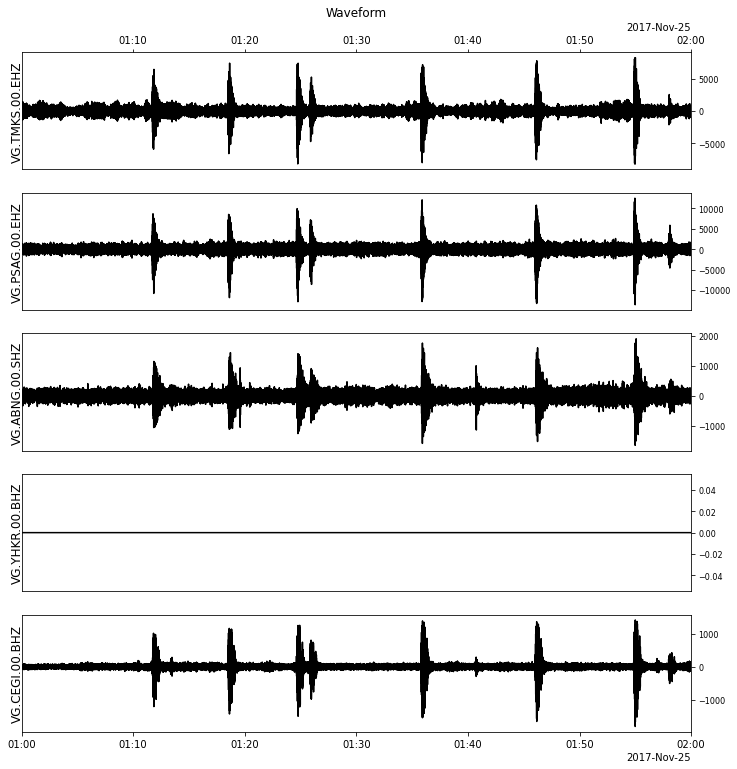

In [5]:
swarmw(st)

### Swarmg

Currently only plots one Trace


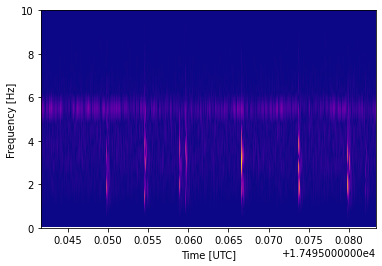

In [6]:
swarmg(st, cmap='plasma')

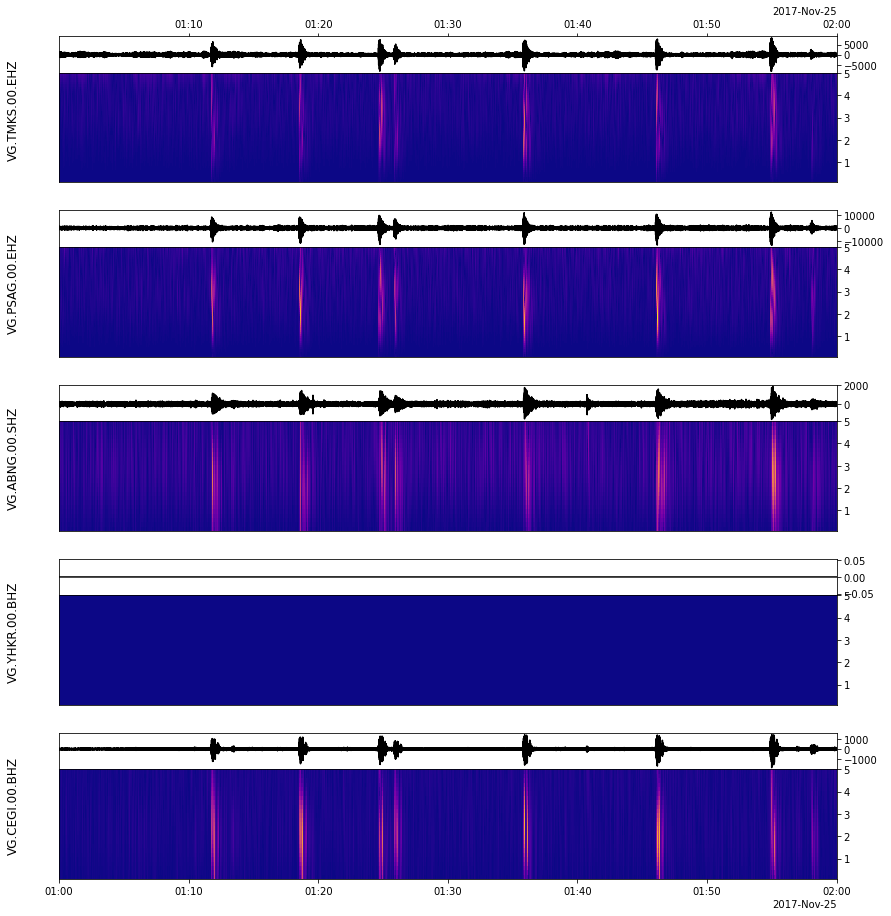

In [7]:
wg = swarmwg(st, gylim=[0.1,5])

### Automatic x-axis adjustments with zoom

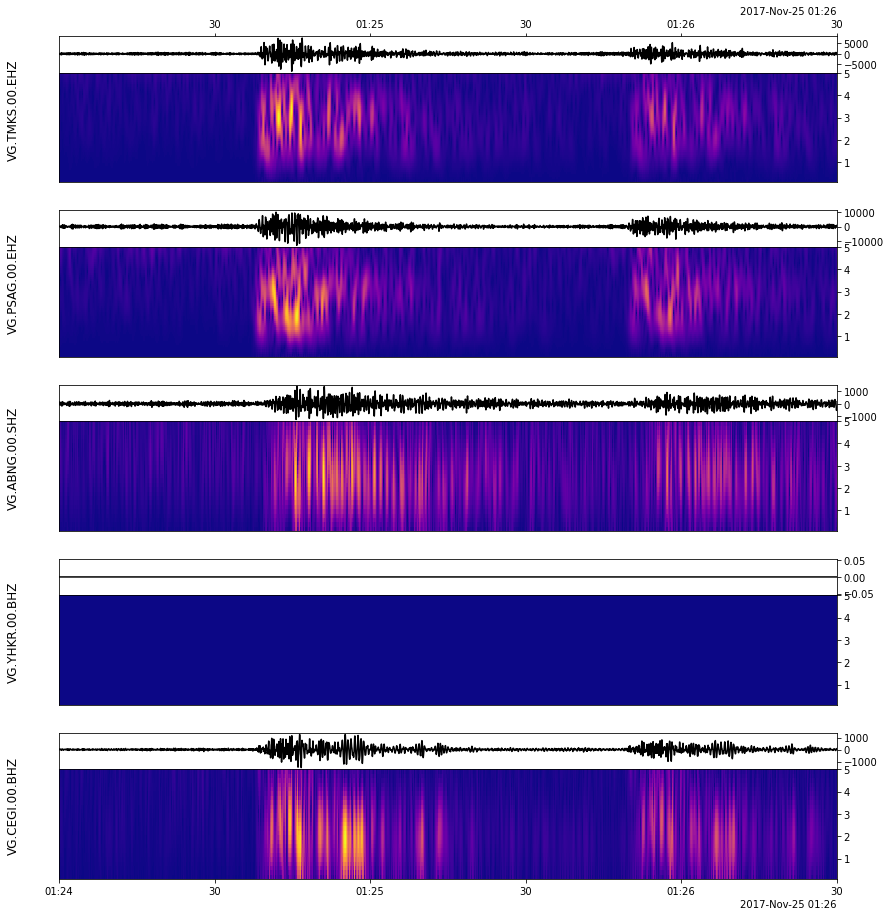

In [8]:
ta = UTCDateTime('2017/11/25 01:24:00')
tb = UTCDateTime('2017/11/25 01:26:30')
wg = swarmwg(st.trim(ta, tb) , gylim=[.1,5])

### Same functionality with single Stream

<AxesSubplot:title={'center':'Waveform'}, ylabel='VG.TMKS.00.EHZ'>

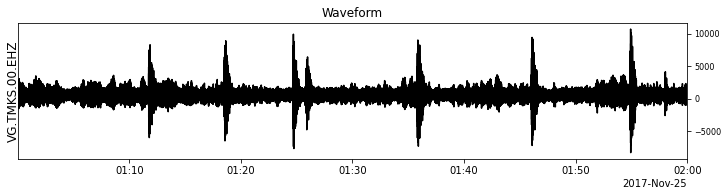

In [9]:
st1 = read('/Users/jaywellik/DATA/continuous/2017/VG/TMKS/EHZ.D/VG.TMKS.00.EHZ.D.2017.329.mseed')
st1 = st1.trim(t1, t2)
swarmw(st1)

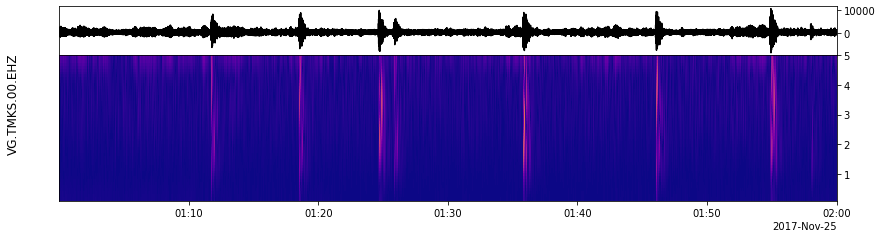

In [10]:
wg = swarmwg(st1, gylim=[0.1,5])